### Lab 01b: Binary Linear Classifier

In this lab you will try making a binary linear classifier using the [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/).

In [43]:
import sklearn
from palmerpenguins import load_penguins
from mlxtend.plotting import plot_decision_regions

The dataset is loaded as a [Pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).  

In [44]:
df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


For simplicity we will drop any rows with missing values (encoded as NaNs).

In [45]:
df.dropna(inplace=True)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's select just the Adelie and Chinstrap penguins.

In [46]:
df = df[(df['species']=='Adelie')|(df['species']=='Chinstrap')]

Now we will grab the flipper length and bill length to be the features (stored in ``X``) and the species as the labels (stored in ``y``).

In [47]:
X = df[['flipper_length_mm','bill_length_mm']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

## Exercises

1. Fit a binary linear classifier using scikit-learn (see ``sklearn.linear_model.LogisticRegression``).

Plot the resulting classifier using ``plot_decision_regions(X, y, clf=model)``.


<Axes: >

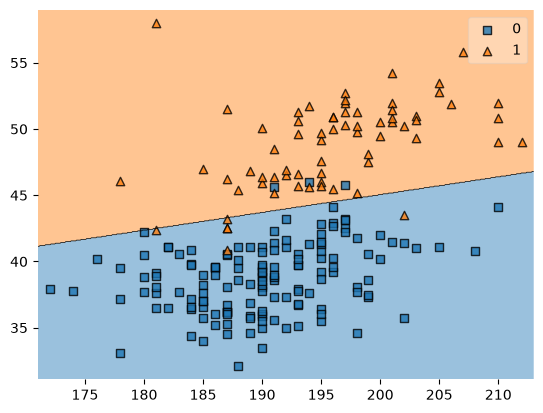

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model = model.fit(X,y)

plot_decision_regions(X,y,clf=model)

2. Print out the coefficients of the line (``model.coef_``).  Interpret these values (in terms of the direction of the line and also what they tell us about how the classifier operates).

In [49]:
model.coef_

array([[-0.15845623,  1.17936568]])

The weights -0.15845623,  1.17936568 indicate the magnitude and direction in which the flipper and bill length of the Adelie and Chinstrap penguins are predictive of their species.

3. Calculate and print out the accuracy of the classifier using the `.score` function.  Interpret this value.

In [50]:
model.score(X,y)

0.9579439252336449

The model is able to correctly identify the species of 95.8% of the penguins in this dataset.

4. Try different combinations of features and print out the accuracy for each one.  Interpret your results.

In [55]:
new_X = df[['bill_depth_mm','body_mass_g']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

new_model = LogisticRegression()
new_model = new_model.fit(new_X,y)

print(f"New model with bill depth (mm) and body mass (g) scores at: {round(new_model.score(new_X,y),2)}, pretty okay")
print()
print("Let's try something new: body mass (g) and flipper length (mm)")

new_new_X = df[['flipper_length_mm','body_mass_g']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

new_new_model = LogisticRegression()
new_new_model = new_new_model.fit(new_new_X,y)

print(f"New model with flipper length (mm) and body mass (g) scores at: {round(new_new_model.score(new_new_X,y),2)}, a little better")

print("The newer two models result in 68 and 74 percent accuracy, meaning they identified the \ncorrect species of the penguins 68 and 74 percent of the time, respectively")

New model with bill depth (mm) and body mass (g) scores at: 0.68, pretty okay

Let's try something new: body mass (g) and flipper length (mm)
New model with flipper length (mm) and body mass (g) scores at: 0.74, a little better
The newer two models result in 68 and 74 percent accuracy, meaning they identified the 
correct species of the penguins 68 and 74 percent of the time, respectively
